In [1]:
from utils import Utils
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# df = Utils.create_df("./d
# ata/anonymized_data/")
# pd.DataFrame(df).reset_index().to_csv("data/created_df.csv", index=False)
df = pd.read_csv("data/created_df.csv")
df["date"] = pd.to_datetime(df["date"])
n = 100
df = Utils.get_first_n_assets(df, n)
features = Utils.add_signals(Utils.get_features(df).dropna())

In [3]:
features.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'tic', 'log-ret',
       'boll', 'boll_ub', 'boll_lb', 'rsi_6', 'rsi', 'cci_6', 'cci', 'dx',
       'adx', 'adxr', 'close_5_sma', 'close_20_ema', 'close_5_ema', 'cci_5',
       'pdi', 'ndi', 'stochrsi_3', 'macd', 'macds', 'macdh', 'tema', 'pvo',
       'pvos', 'pvoh', 'macd_signal', 'rsi_signal', 'adx_signal', 'cci_signal',
       'boll_signal', 'macd_signal_held', 'rsi_signal_held', 'adx_signal_held',
       'cci_signal_held', 'boll_signal_held'],
      dtype='str')

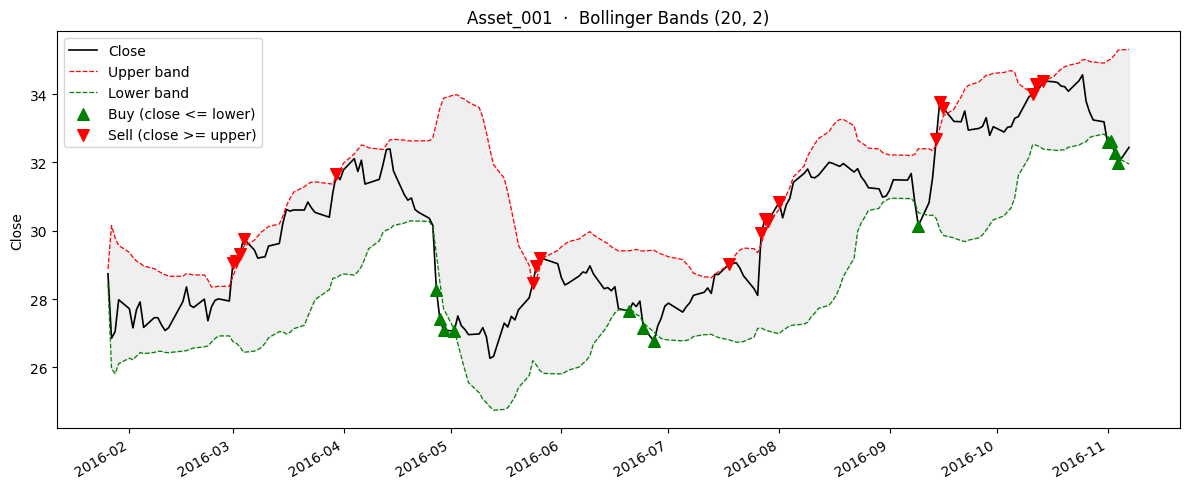

In [4]:
one = features[features["tic"] == features["tic"].iloc[0]].reset_index(drop=True)
px = one.iloc[:200]
dates = pd.to_datetime(px["date"])
buy, sell = px["boll_signal"] == 1, px["boll_signal"] == -1

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates, px["close"], color="black", lw=1.2, label="Close")
ax.plot(dates, px["boll_ub"], color="r", lw=0.9, ls="--", label="Upper band")
ax.plot(dates, px["boll_lb"], color="g", lw=0.9, ls="--", label="Lower band")
ax.fill_between(dates, px["boll_lb"], px["boll_ub"], color="0.85", alpha=0.4)
ax.scatter(dates[buy], px.loc[buy, "close"], marker="^", s=70, color="green", zorder=3, label="Buy (close <= lower)")
ax.scatter(dates[sell], px.loc[sell, "close"], marker="v", s=70, color="red", zorder=3, label="Sell (close >= upper)")
ax.set_title(f"{one['tic'].iloc[0]}  ·  Bollinger Bands (20, 2)")
ax.set_ylabel("Close")
ax.legend(loc="upper left")
fig.autofmt_xdate(); fig.tight_layout(); plt.show()

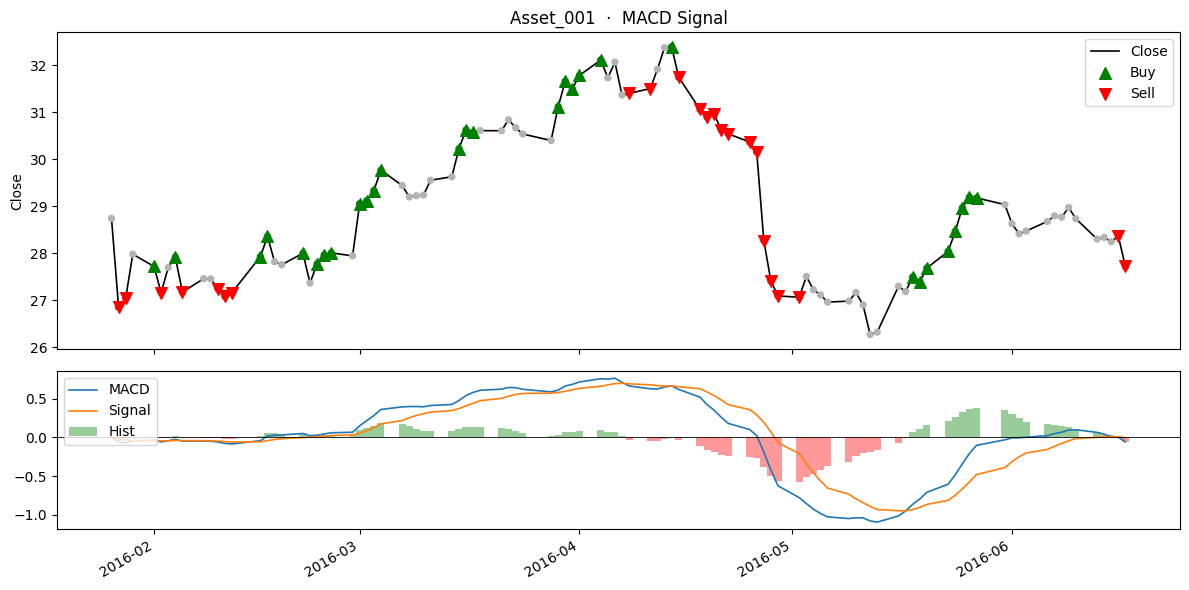

In [5]:
one = features[features["tic"] == features["tic"].iloc[0]].reset_index(drop=True).copy()
signal = one[["date", "macd_signal", "rsi_signal", "adx_signal", "cci_signal"]].copy()
sig = one['macd_signal']
label = "MACD Signal"

window = slice(None, 100)  # first 100 bars; use slice(None) for all
px = one.loc[window]
s = px['macd_signal']
dates = pd.to_datetime(px["date"])
close = px["close"]

buy = s == 1
sell = s == -1

fig, (ax, ax_m) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax.plot(dates, close, color="black", lw=1.2, label="Close")
ax.scatter(dates, close, c=["g" if v == 1 else "r" if v == -1 else "0.7" for v in s], s=18, zorder=3)
ax.scatter(dates[buy], close[buy], marker="^", s=70, color="green", zorder=4, label="Buy")
ax.scatter(dates[sell], close[sell], marker="v", s=70, color="red", zorder=4, label="Sell")
ax.set_title(f"{one['tic'].iloc[0]}  ·  {label}"); ax.set_ylabel("Close"); ax.legend()
ax_m.plot(dates, px["macd"], color="C0", lw=1.2, label="MACD"); ax_m.plot(dates, px["macds"], color="C1", lw=1.2, label="Signal")
ax_m.bar(dates, px["macdh"], color=["g" if v >= 0 else "r" for v in px["macdh"]], width=1.0, alpha=0.4, label="Hist")
ax_m.axhline(0, color="k", lw=0.6); ax_m.legend(loc="upper left")
fig.autofmt_xdate(); fig.tight_layout(); plt.show()

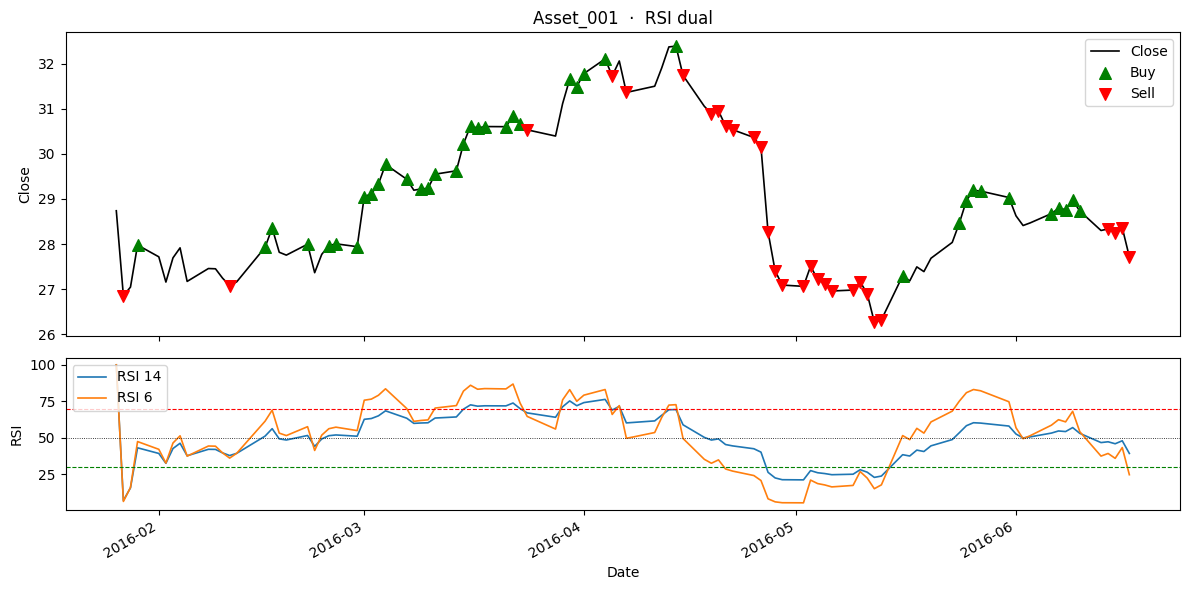

In [6]:
one = features[features["tic"] == features["tic"].iloc[0]].reset_index(drop=True).copy()
rsi_sig = one['rsi_signal']
# macd_cross, macd_zero = Utils.get_macd_signal(one["macd"], one["macds"], one["macdh"])

# pick the series to draw: rsi_sig, macd_cross, or macd_zero
sig = rsi_sig
label = "RSI dual"

window = slice(None, 100)  # first 100 bars; use slice(None) for all
px = one.loc[window]
s = px['rsi_signal']
dates = pd.to_datetime(px["date"])
close = px["close"]

buy = s == 1
sell = s == -1

fig, (ax, ax_r) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
ax.plot(dates, close, color="black", lw=1.2, label="Close")
ax.scatter(dates[buy], close[buy], marker="^", s=70, color="green", zorder=3, label="Buy")
ax.scatter(dates[sell], close[sell], marker="v", s=70, color="red", zorder=3, label="Sell")
ax.set_title(f"{one['tic'].iloc[0]}  ·  {label}")
ax.set_ylabel("Close")
ax.legend()

ax_r.plot(dates, px["rsi"], color="C0", lw=1.2, label="RSI 14")
ax_r.plot(dates, px["rsi_6"], color="C1", lw=1.2, label="RSI 6")
ax_r.axhline(70, color="r", ls="--", lw=0.8)
ax_r.axhline(30, color="g", ls="--", lw=0.8)
ax_r.axhline(50, color="k", ls=":", lw=0.6)
ax_r.set_ylabel("RSI")
ax_r.set_xlabel("Date")
ax_r.legend(loc="upper left")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

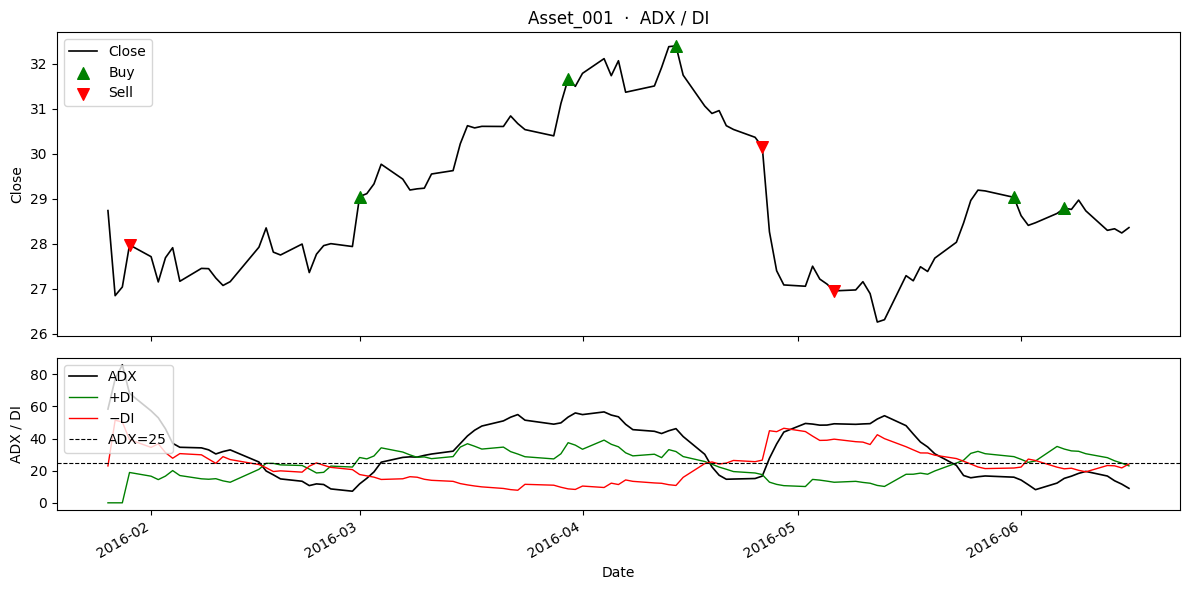

In [7]:
one = features[features["tic"] == features["tic"].iloc[0]].reset_index(drop=True).copy()
adx_sig = one["adx_signal"]
label = "ADX Signal"

window = slice(None, 100)
px = one.iloc[window]
s = px["adx_signal"]
changed = s != s.shift()
buy = (s == 1) & changed
sell = (s == -1) & changed
dates = pd.to_datetime(px["date"])
close = px["close"]

fig, (ax_px, ax_adx) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

ax_px.plot(dates, close, color="black", lw=1.2, label="Close")
ax_px.scatter(dates[buy], close[buy], marker="^", s=70, color="green", zorder=3, label="Buy")
ax_px.scatter(dates[sell], close[sell], marker="v", s=70, color="red", zorder=3, label="Sell")
ax_px.set_ylabel("Close")
ax_px.set_title(f"{one['tic'].iloc[0]}  ·  ADX / DI")
ax_px.legend(loc="upper left")

ax_adx.plot(dates, px["adx"], color="black", lw=1.2, label="ADX")
ax_adx.plot(dates, px["pdi"], color="green", lw=1.0, label="+DI")
ax_adx.plot(dates, px["ndi"], color="red", lw=1.0, label="−DI")
ax_adx.axhline(25, color="k", ls="--", lw=0.8, label="ADX=25")
ax_adx.set_ylabel("ADX / DI")
ax_adx.set_xlabel("Date")
ax_adx.legend(loc="upper left")

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

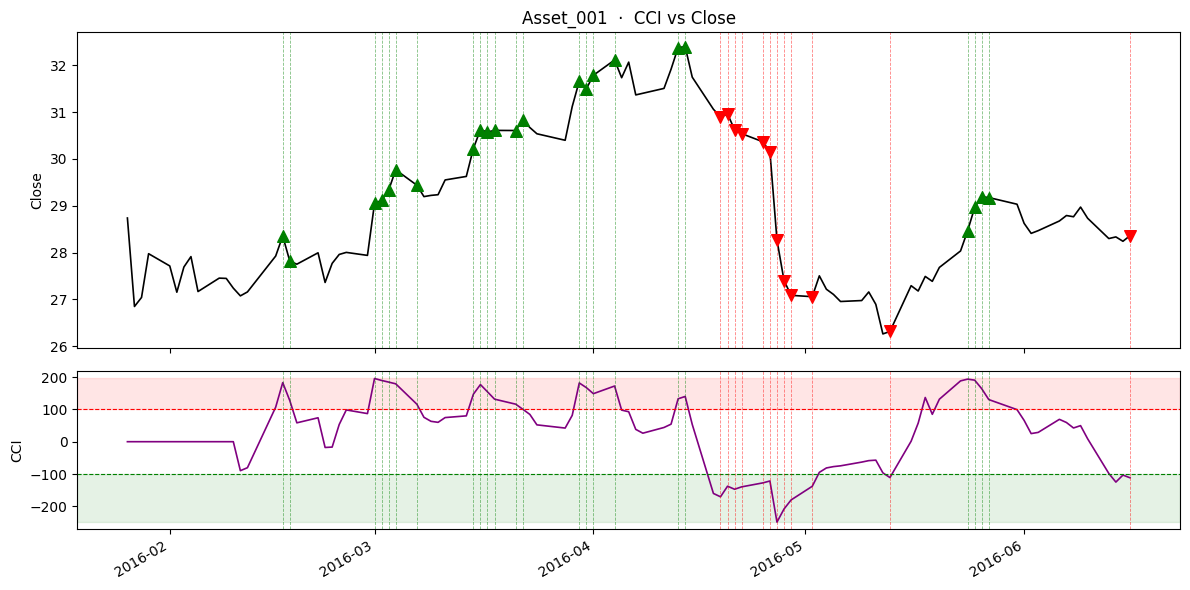

In [8]:
one = features[features["tic"] == features["tic"].iloc[0]].reset_index(drop=True).copy()
window = slice(None, 100)
px = one.iloc[window]
dates = pd.to_datetime(px["date"])
s = px["cci_signal"]
buy, sell = s == 1, s == -1
fig, (ax_px, ax_cci) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
ax_px.plot(dates, px["close"], color="black", lw=1.2, label="Close")
ax_px.scatter(dates[buy], px.loc[buy, "close"], marker="^", s=70, color="green", zorder=3, label="Buy")
ax_px.scatter(dates[sell], px.loc[sell, "close"], marker="v", s=70, color="red", zorder=3, label="Sell")
ax_px.set_ylabel("Close")
ax_px.set_title(f"{one['tic'].iloc[0]}  ·  CCI vs Close")
ax_cci.plot(dates, px["cci"], color="purple", lw=1.2, label="CCI")
ax_cci.axhline(100, color="r", ls="--", lw=0.8)
ax_cci.axhline(-100, color="g", ls="--", lw=0.8)
ax_cci.axhspan(100, px["cci"].max(), color="r", alpha=0.1)
ax_cci.axhspan(px["cci"].min(), -100, color="g", alpha=0.1)
ax_cci.set_ylabel("CCI")
[ax.axvline(d, color="g" if b else "r", ls="--", lw=0.6, alpha=0.5) for ax in (ax_px, ax_cci) for d, b, se in zip(dates, buy, sell) if b or se]
fig.autofmt_xdate(); fig.tight_layout(); plt.show()


In [9]:
# Held columns are built in Utils.add_signals, per ticker in date order.
# Check: held only changes on a non-zero raw signal that differs from the previous held value.
for col in Utils.SIGNAL_COLS:
    bad = 0
    for _, g in features.groupby("tic", sort=False):
        g = g.sort_values("date")
        raw, held = g[col].to_numpy(), g[col + "_held"].to_numpy()
        prev = np.r_[0, held[:-1]]
        changed = held != prev
        bad += int((changed & ((raw == 0) | (raw == prev))).sum())
        bad += int((~changed & (raw != 0) & (raw != prev)).sum())
    flips = int(features.groupby("tic")[col + "_held"].apply(lambda s: (s.diff().fillna(0) != 0).sum()).sum())
    print(f"{col + '_held':18s} violations={bad}  flips={flips}  raw non-zero={(features[col] != 0).mean():.3f}")

macd_signal_held   violations=0  flips=20277  raw non-zero=0.531
rsi_signal_held    violations=0  flips=28228  raw non-zero=0.563
adx_signal_held    violations=0  flips=9358  raw non-zero=0.496
cci_signal_held    violations=0  flips=11581  raw non-zero=0.391
boll_signal_held   violations=0  flips=5501  raw non-zero=0.107


In [10]:
features.head()

,date,open,high,low,close,volume,tic,log-ret,boll,boll_ub,...,macd_signal,rsi_signal,adx_signal,cci_signal,boll_signal,macd_signal_held,rsi_signal_held,adx_signal_held,cci_signal_held,boll_signal_held
0,2016-01-26,28.721415,28.994458,28.186822,28.738659,361581962,Asset_001,0.005515,28.659626,28.883166,...,0,0,0,0,0,0,0,0,0,0
1,2016-01-26,62.871551,63.660630,62.580196,63.332857,21245259,Asset_002,0.007310,63.102210,63.754579,...,0,0,0,0,0,0,0,0,0,0
2,2016-01-26,36.440445,36.666587,36.064223,36.399096,35025737,Asset_003,0.001923,36.364125,36.463038,...,0,0,0,0,0,0,0,0,0,0
3,2016-01-26,34.521994,34.582061,33.774287,34.396136,54641788,Asset_004,0.007881,34.261126,34.642992,...,0,0,0,0,0,0,0,0,0,0
4,2016-01-26,0.909773,0.920634,0.900509,0.916801,174600456,Asset_005,0.009804,0.912328,0.924977,...,0,0,0,0,0,0,0,0,0,0


### IC IR Test for the signals

In [11]:
# icir_df = Utils.get_ic(features)
# icir_df.sort_values(["h", "ICIR"], ascending=[True, False])

# Fails

In [12]:
features['macd']

0          0.003546
1          0.010350
2          0.001569
3          0.006058
4          0.000201
            ...    
250995     2.685019
250996    25.667950
250997     1.678820
250998     8.114562
250999    -0.020508
Name: macd, Length: 251000, dtype: float64

In [13]:
# Trailing-window z-score (default 10 days, no look-ahead)
standardize = Utils.rolling_standardize

In [14]:
features['macd_stad'] = features.groupby('tic')['macd'].transform(standardize)
features['macds_stad'] = features.groupby('tic')['macds'].transform(standardize)
features['macdh_stad'] = features.groupby('tic')['macdh'].transform(standardize)


<Axes: >

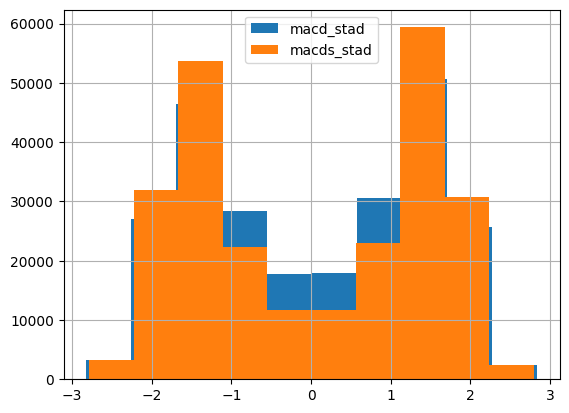

In [15]:
features['macd_stad'].hist(legend = True)
features['macds_stad'].hist(legend = True)

In [16]:
print(features['macd_stad'].describe())
print(features['macds_stad'].describe())

count    250100.000000
mean          0.017667
std           1.381815
min          -2.824624
25%          -1.310804
50%           0.076673
75%           1.325596
max           2.837070
Name: macd_stad, dtype: float64
count    250100.000000
mean          0.021424
std           1.447366
min          -2.784766
25%          -1.412645
50%           0.119769
75%           1.424294
max           2.795405
Name: macds_stad, dtype: float64


In [17]:
features['tema_stad'] = features.groupby('tic')['tema'].transform(standardize)
features['pvo_stad'] = features['pvo'] / 100
features['pvos_stad'] = features['pvos'] / 100
features['pvoh_stad'] = features['pvoh'] / 100

0


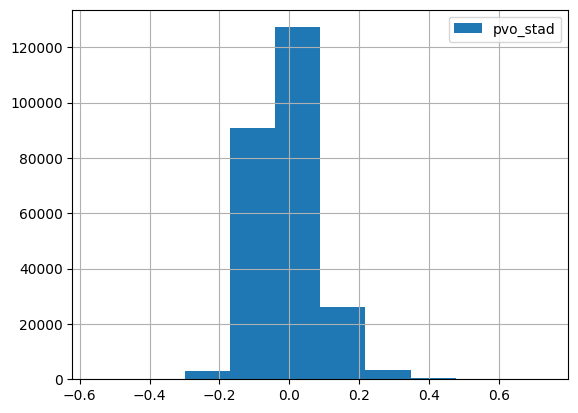

In [18]:
features['pvo_stad'].hist(legend = True)
print((features['pvo_stad'].abs() > 1).sum())

count    250100.000000
mean         -0.013507
std           0.951081
min          -2.831948
25%          -0.644302
50%          -0.008858
75%           0.630099
max           2.836451
Name: log-ret_stad, dtype: float64


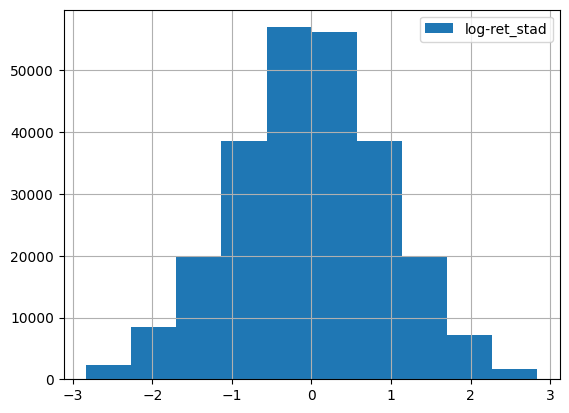

In [19]:
features['log-ret_stad'] = features.groupby('tic')['log-ret'].transform(standardize)
features['log-ret_stad'].hist(legend = True)
print(features['log-ret_stad'].describe())

In [20]:
features['adx_scale'] = features.groupby('tic')['adx'].transform(Utils.rolling_minmax)
features['pdi_scale'] = features.groupby('tic')['pdi'].transform(Utils.rolling_minmax)
features['ndi_scale'] = features.groupby('tic')['ndi'].transform(Utils.rolling_minmax)
features[['adx_scale', 'pdi_scale', 'ndi_scale']].describe()

,adx_scale,pdi_scale,ndi_scale
count,250100.000000,250100.000000,250100.000000
mean,0.484159,0.455789,0.427490
std,0.417046,0.377989,0.375263
min,0.000000,0.000000,0.000000
25%,0.000000,0.013859,0.000000
50%,0.447040,0.443297,0.391750
75%,1.000000,0.818575,0.783010
max,1.000000,1.000000,1.000000


In [21]:
# Scale-free versions of the raw inputs, for the RL agent's observation in task3.
# Raw volume (up to ~1e9) and close (up to ~1e3) saturate the networks, so the agent sees these instead.
ROLL_WINDOW = 10   # window of Utils.rolling_standardize / rolling_minmax
features['volume_stad'] = features.groupby('tic')['volume'].transform(standardize)
band_width = (features['boll_ub'] - features['boll_lb']).replace(0, np.nan)
features['boll_pctb'] = ((features['close'] - features['boll_lb']) / band_width).clip(-1, 2)
features['rsi_6_scale'] = features['rsi_6'] / 100
features['stochrsi_3_scale'] = features['stochrsi_3'] / 100

# A window with zero spread (flat price or volume) gives NaN. After each tic's warm-up rows,
# use the neutral value instead of dropping the row, so every tic keeps a row on every date.
zscore_cols = ['macd_stad', 'macds_stad', 'macdh_stad', 'tema_stad', 'log-ret_stad', 'volume_stad']   # neutral 0
unit_cols = ['adx_scale', 'pdi_scale', 'ndi_scale', 'boll_pctb']                          # neutral 0.5
warmed_up = features.groupby('tic').cumcount() >= ROLL_WINDOW - 1
for cols, neutral in ((zscore_cols, 0.0), (unit_cols, 0.5)):
    filled = features[cols].replace([np.inf, -np.inf], np.nan).fillna(neutral)
    features.loc[warmed_up, cols] = filled.loc[warmed_up]
features[zscore_cols + unit_cols + ['rsi_6_scale', 'stochrsi_3_scale']].describe().T[['mean', 'min', 'max']]


,mean,min,max
macd_stad,0.017667,-2.824624,2.837070
macds_stad,0.021424,-2.784766,2.795405
macdh_stad,-0.024426,-2.819107,2.832760
tema_stad,0.175657,-2.828646,2.835713
log-ret_stad,-0.013507,-2.831948,2.836451
volume_stad,0.002278,-2.684358,2.843629
adx_scale,0.484159,0.000000,1.000000
pdi_scale,0.455789,0.000000,1.000000
ndi_scale,0.427490,0.000000,1.000000
boll_pctb,0.560897,-0.531733,1.558492


In [22]:
from pathlib import Path
panel_cols = [
    "date",
    "tic",
    "close",
    "volume",
    "rsi_6",
    "stochrsi_3",
    "boll_ub",
    "boll_lb",
    "boll_pctb",
    "volume_stad",
    "rsi_6_scale",
    "stochrsi_3_scale",
    "macd_stad",
    "macds_stad",
    "macdh_stad",
    "tema_stad",
    "pvo_stad",
    "pvos_stad",
    "pvoh_stad",
    "log-ret_stad",
    "adx_scale",
    "pdi_scale",
    "ndi_scale",
] + Utils.SIGNAL_COLS + [c + "_held" for c in Utils.SIGNAL_COLS]
panel = features[panel_cols].replace([np.inf, -np.inf], np.nan).dropna().sort_values(["date", "tic"])
out = Path("./data/features_panel.csv")
panel.to_csv(out, index=False)
print(out, panel.shape, "tickers:", panel["tic"].nunique())


data/features_panel.csv (250100, 33) tickers: 100


## LightGBM: next-day return

Target is each asset's own next-day log return. One pooled model is trained over all assets.

The signal set has overlapping columns (for example each signal and its `_held` version). Clear duplicates are pruned by hand first (`pruned_cols`). PCA then turns the remaining correlated features into a smaller set of uncorrelated components.


In [23]:
from sklearn.metrics import mean_squared_error as mse

data = features.sort_values(["tic", "date"]).reset_index(drop=True)
data["y"] = data.groupby("tic")["close"].shift(-1)
data = data.replace([np.inf, -np.inf], np.nan)

drop_cols = ['date', 'tic', 'log-ret', 'y', 'open', 'high', 'low', 'volume',
             'macd', 'macds', 'macdh', 'tema', 'pvo', 'pvoh', 'pvos', 'cci', 'rsi', 'pdi', 'ndi',
             # scaled copies added for the RL observation; kept out of the LightGBM inputs
             'volume_stad', 'boll_pctb', 'rsi_6_scale', 'stochrsi_3_scale']
# Raw price levels differ by asset and trend over time. In a pooled PCA they form
# their own component that only tells the model which asset it is looking at.
price_level_cols = ['close', 'boll', 'boll_ub', 'boll_lb', 'close_5_sma', 'close_20_ema', 'close_5_ema']
# Near-duplicates: cci_5 ~ cci_6 (|rho| 0.97); adx / adxr / dx are the same trend strength, kept as adx_scale.
pruned_cols = ['cci_5', 'adxr', 'adx', 'dx']
feature_cols = [c for c in data.columns if c not in drop_cols + price_level_cols + pruned_cols]
data = data.dropna(subset=feature_cols + ["y"]).reset_index(drop=True)
print(len(feature_cols), feature_cols)


24 ['rsi_6', 'cci_6', 'stochrsi_3', 'macd_signal', 'rsi_signal', 'adx_signal', 'cci_signal', 'boll_signal', 'macd_signal_held', 'rsi_signal_held', 'adx_signal_held', 'cci_signal_held', 'boll_signal_held', 'macd_stad', 'macds_stad', 'macdh_stad', 'tema_stad', 'pvo_stad', 'pvos_stad', 'pvoh_stad', 'log-ret_stad', 'adx_scale', 'pdi_scale', 'ndi_scale']


### PCA analysis: how many components?

PCA is fit on the first 80% of dates only, so the choice of components does not use the last part of the data. Features are standardized first, because PCA is scale-sensitive.


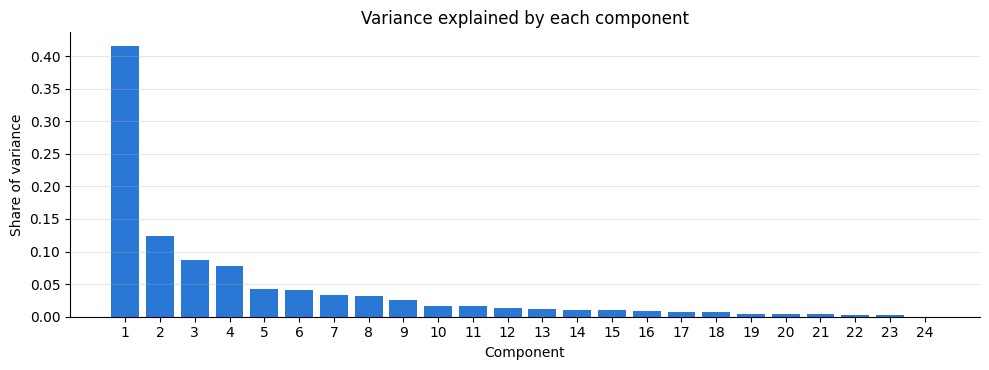

Components needed: {'80%': 7, '90%': 11, '95%': 15}


In [24]:
dates = np.sort(data["date"].unique())
pca_fit_rows = data["date"] < dates[int(len(dates) * 0.8)]

pca_full = Utils.fit_pca(data.loc[pca_fit_rows, feature_cols])   # keep all components
variance, needed = Utils.plot_pca_variance(pca_full)
print("Components needed:", {f"{t:.0%}": k for t, k in needed.items()})


### Choosing N: cumulative variance

The curve flattens after the first few components, so each extra component adds less new information. N is the smallest number of components that keeps 90% of the variance. The components after N (gray) together hold under 10% of the variance, mostly noise and near-duplicate columns.


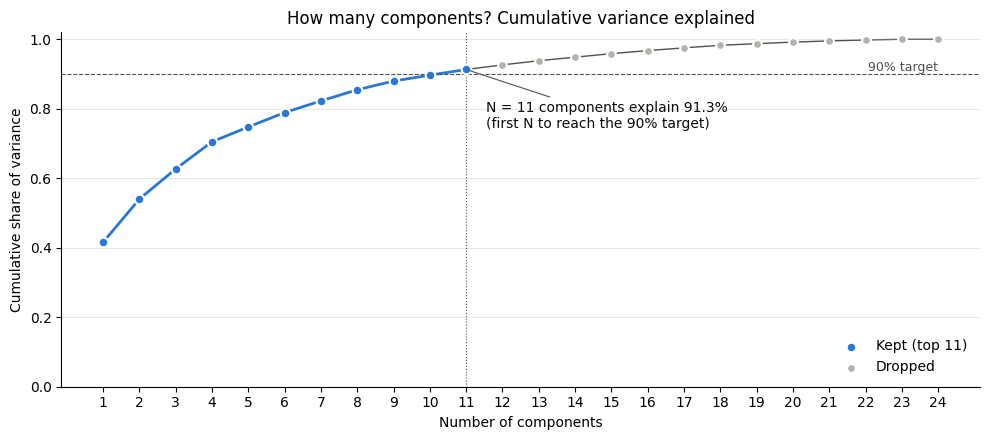

Top 11 components (91.3% of variance):
   PC1   41.6%  (cum  41.6%)  tema_stad (+0.29), rsi_6 (+0.29), cci_signal (+0.27)
   PC2   12.5%  (cum  54.0%)  adx_signal_held (+0.41), cci_signal_held (+0.36), boll_signal_held (-0.36)
   PC3    8.7%  (cum  62.7%)  pvo_stad (+0.51), pvos_stad (+0.41), log-ret_stad (-0.34)
   PC4    7.8%  (cum  70.5%)  pvo_stad (+0.36), pvoh_stad (+0.35), boll_signal_held (-0.33)
   PC5    4.3%  (cum  74.8%)  adx_scale (+0.68), pvos_stad (-0.47), pvoh_stad (+0.38)
   PC6    4.1%  (cum  78.9%)  macds_stad (+0.39), macdh_stad (-0.36), macd_signal_held (+0.34)
   PC7    3.4%  (cum  82.3%)  boll_signal (+0.52), adx_scale (+0.45), pvoh_stad (-0.43)
   PC8    3.2%  (cum  85.5%)  boll_signal (+0.47), pvoh_stad (+0.47), adx_scale (-0.42)
   PC9    2.5%  (cum  88.0%)  rsi_signal_held (+0.63), boll_signal (-0.44), rsi_signal (+0.40)
  PC10    1.7%  (cum  89.7%)  boll_signal_held (+0.78), boll_signal (-0.32), cci_signal_held (+0.30)
  PC11    1.6%  (cum  91.3%)  cci_signal

In [25]:
VARIANCE_TARGET = 0.90
N_COMPONENTS = Utils.plot_cumulative_variance(pca_full, target=VARIANCE_TARGET)

top_components = Utils.component_summary(pca_full, feature_cols, N_COMPONENTS, k=3)
print(f"Top {N_COMPONENTS} components ({top_components['cumulative'].iloc[-1]:.1%} of variance):")
for pc, row in top_components.iterrows():
    print(f"  {pc:>4}  {row['explained']:6.1%}  (cum {row['cumulative']:6.1%})  {row['top_features']}")


### Top components: what does each one capture?

Loadings are each feature's weight on a component. Large absolute values (dark red or blue) show which features make up that component.


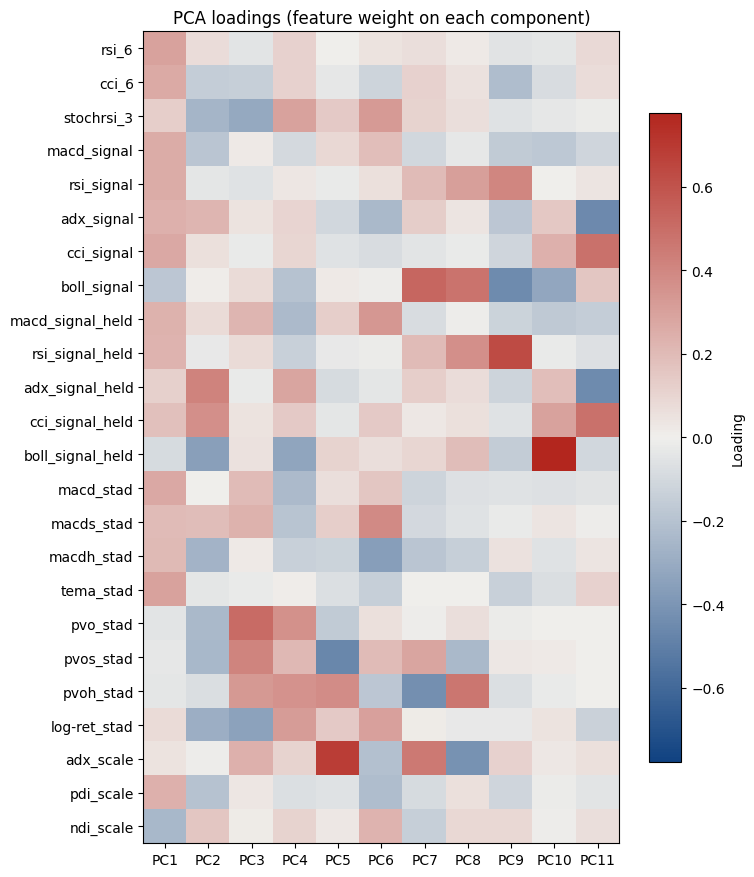

,#1,#2,#3,#4,#5
PC1,tema_stad (+0.29),rsi_6 (+0.29),cci_signal (+0.27),macd_stad (+0.27),cci_6 (+0.26)
PC2,adx_signal_held (+0.41),cci_signal_held (+0.36),boll_signal_held (-0.36),log-ret_stad (-0.29),macdh_stad (-0.27)
PC3,pvo_stad (+0.51),pvos_stad (+0.41),log-ret_stad (-0.34),pvoh_stad (+0.33),stochrsi_3 (-0.32)
PC4,pvo_stad (+0.36),pvoh_stad (+0.35),boll_signal_held (-0.33),log-ret_stad (+0.32),stochrsi_3 (+0.30)
PC5,adx_scale (+0.68),pvos_stad (-0.47),pvoh_stad (+0.38),pvo_stad (-0.16),stochrsi_3 (+0.14)
PC6,macds_stad (+0.39),macdh_stad (-0.36),macd_signal_held (+0.34),stochrsi_3 (+0.32),log-ret_stad (+0.30)
PC7,boll_signal (+0.52),adx_scale (+0.45),pvoh_stad (-0.43),pvos_stad (+0.29),rsi_signal_held (+0.20)
PC8,boll_signal (+0.47),pvoh_stad (+0.47),adx_scale (-0.42),rsi_signal_held (+0.37),rsi_signal (+0.30)
PC9,rsi_signal_held (+0.63),boll_signal (-0.44),rsi_signal (+0.40),cci_6 (-0.22),adx_signal (-0.18)
PC10,boll_signal_held (+0.78),boll_signal (-0.32),cci_signal_held (+0.30),cci_signal (+0.24),adx_signal_held (+0.19)


In [26]:
loadings = Utils.pca_loadings(pca_full, feature_cols, N_COMPONENTS)
Utils.plot_pca_loadings(loadings)
Utils.top_loadings(loadings, k=5)


### Raw features vs PCA

Walk-forward CV (5 expanding folds, split on dates). The scaler and PCA are refit inside every training fold. `rmse_zero` is the RMSE of always predicting 0, the baseline to beat. `ic` is the mean daily cross-sectional Spearman IC.


In [27]:
LGB_PARAMS = dict(max_depth=8, objective="regression", metric="rmse", num_leaves=100, learning_rate=0.05)
setups = {
    "raw features": None,
    "PCA 3": 3,
    "PCA 80%": 0.80,
    "PCA 90%": 0.90,
    "PCA 95%": 0.95,
}
comparison = {}
for name, n_components in setups.items():
    _, fold_metrics = Utils.lgb_walk_forward(data, feature_cols, n_components=n_components, lgb_params=LGB_PARAMS)
    comparison[name] = fold_metrics[["n_inputs", "rmse", "rmse_zero", "ic", "hit"]].mean()
pd.DataFrame(comparison).T.round(5)


,n_inputs,rmse,rmse_zero,ic,hit
raw features,24.00,225.41961,284.86875,0.02826,1.0
PCA 3,3.00,225.40500,284.86875,0.01530,1.0
PCA 80%,0.80,225.45302,284.86875,0.02310,1.0
PCA 90%,0.90,225.53896,284.86875,0.02623,1.0
PCA 95%,0.95,225.60804,284.86875,0.02237,1.0


### Final model


In [28]:
preds, fold_metrics = Utils.lgb_walk_forward(data, feature_cols, n_components=N_COMPONENTS, lgb_params=LGB_PARAMS)
fold_metrics.round(5)


,fold,train_rows,val_rows,n_inputs,rmse,rmse_zero,ic,hit
0,1,42000,41600,11,139.10482,177.64095,0.03126,1.0
1,2,83600,41600,11,154.95532,205.04132,0.03078,1.0
2,3,125200,41600,11,207.22341,271.07786,0.05133,1.0
3,4,166800,41600,11,244.68965,314.35704,0.02190,1.0
4,5,208400,41600,11,381.72159,456.22659,-0.00410,1.0


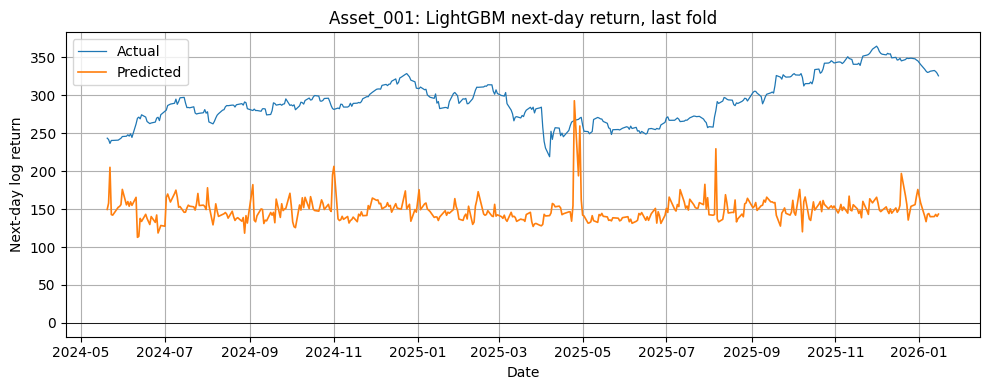

,rmse,rmse_zero
tic,,
Asset_038,20.983798,143.081561
Asset_023,21.270408,146.931233
Asset_040,25.673299,127.032897
Asset_094,26.578488,127.050050
Asset_043,29.669879,128.271105
Asset_073,31.999094,169.941685
Asset_049,34.212230,116.404497
Asset_057,34.429098,123.236228
Asset_089,34.915127,121.120886


In [29]:
last = preds[preds["fold"] == preds["fold"].max()]
tic0 = last["tic"].iloc[0]
one = last[last["tic"] == tic0].sort_values("date")

plt.figure(figsize=(10, 4))
plt.plot(pd.to_datetime(one["date"]), one["y"], label="Actual", lw=0.9)
plt.plot(pd.to_datetime(one["date"]), one["pred"], label="Predicted", lw=1.2)
plt.axhline(0, color="k", lw=0.6)
plt.xlabel("Date")
plt.ylabel("Next-day log return")
plt.title(f"{tic0}: LightGBM next-day return, last fold")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

rmse_by_tic = last.groupby("tic").apply(
    lambda g: pd.Series({
        "rmse": np.sqrt(mse(g["y"], g["pred"])),
        "rmse_zero": np.sqrt(mse(g["y"], np.zeros(len(g)))),
    })
)
rmse_by_tic.sort_values("rmse").head(10)


In [30]:
# Variation Inflation Factor : 
# VIF = 1 / (1 - R^2)

## Rolling 3-month asset correlation

Each asset is a matrix of its features over the previous 63 trading sessions (about three months). For a pair of assets, each feature contributes one correlation between their two columns, so the pair gets a correlation vector. The score is the magnitude of that vector. Raw price levels are left out of the matrix; they repeat the same path.


In [31]:
scores, vectors, history = Utils.feature_pair_correlation(features)
print(
    f"{scores.attrs['start']:%Y-%m-%d} to {scores.attrs['end']:%Y-%m-%d}",
    f"{scores.shape[0]} assets,",
    f"{len(scores.attrs['features'])} features,",
    f"mean score {history.iloc[-1]:.3f}",
)
print("Features:", ", ".join(scores.attrs["features"]))
Utils.plot_asset_corr(scores)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(history.index, history.values, lw=1.2)
ax.set_title("Mean pair score, trailing 63 sessions")
ax.set_xlabel("Date")
ax.set_ylabel("Mean magnitude")
fig.tight_layout()
plt.show()

pairs = Utils.asset_corr_pairs(scores)
print("Highest scores")
display(pairs.head(10))
top = pairs.iloc[0]
print(f"Correlation vector: {top.asset_a} vs {top.asset_b}")
display(vectors.loc[(top.asset_a, top.asset_b)].rename("corr").sort_values(key=lambda s: s.abs(), ascending=False).to_frame())


ValueError: all input arrays must have the same shape